# Property Isn't the Hedge You Think
### How the Moscow housing analysis works, end to end

This notebook reproduces every number and figure in the essay
[*Property Isn't the Hedge You Think*](https://joechrisnaldy.app/blog/property-isnt-the-hedge-you-think).

The claim it tests: when Russia's currency collapsed in 2014, Moscow apartment
prices held in rubles, which is exactly how owners lost about a third of their
wealth in world prices without noticing.

The data is the [Sberbank Russian Housing Market](https://www.kaggle.com/c/sberbank-russian-housing-market)
competition set (30,471 Moscow sales, Aug 2011 to Jun 2015, plus a macro file).
It is not committed to the repo; see `data/README.md` to download `train.csv`
and `macro.csv` into `data/`.

## 1. First look

Before cleaning anything, look at what is there: how many rows, over what dates,
and where the target price sits. The first surprise is in the price column.

In [1]:
import pandas as pd
pd.set_option("display.width", 200)

train = pd.read_csv("data/train.csv", parse_dates=["timestamp"])
print(f"{train.shape[0]:,} sales x {train.shape[1]} columns")
print(f"dates: {train.timestamp.min().date()} to {train.timestamp.max().date()}")
train.price_doc.describe().apply(lambda x: f"{x:,.0f}")

30,471 sales x 292 columns
dates: 2011-08-20 to 2015-06-30


count         30,471
mean       7,123,035
std        4,780,111
min          100,000
25%        4,740,002
50%        6,274,411
75%        8,300,000
max      111,111,112
Name: price_doc, dtype: str

Now the surprise. Hundreds of "sales" are recorded at *exactly* 1 or 2 million
rubles. Real prices do not cluster on perfectly round numbers like that: these
are declared prices for tax purposes, not what changed hands. They have to go.

In [2]:
for v in (1_000_000, 2_000_000):
    print(f"sales at exactly {v:>10,} RUB: {(train.price_doc == v).sum():,}")

sales at exactly  1,000,000 RUB: 747
sales at exactly  2,000,000 RUB: 757


## 2. Cleaning

Three rules, all in `load_clean_train` in `build_series.py`:

1. drop the declared-price fakes (exactly 1M or 2M rubles),
2. drop impossible apartment sizes (`full_sq` at or below 10, or at or above 1,000 m2),
3. compute price per square meter and trim the extreme 1% on each tail.

Everything else stays. The point of showing the row count at each step is that
cleaning is a decision, not a black box.

In [3]:
from build_series import load_clean_train
clean = load_clean_train()
print(f"\n{len(clean):,} transactions remain after cleaning")

rows: 30,471 -> drop 1M/2M fakes -> 28,967 -> area filter -> 28,936 -> psqm trim [26,190, 281,263] -> 28,357

28,357 transactions remain after cleaning


## 3. The mix problem, and the fix

A naive citywide median has a trap. Moscow absorbed the much cheaper "New Moscow"
territories in 2012, and their share of monthly sales swings from roughly 14% to
38%. When cheap districts are a big share of a given month, the citywide median
dips, for reasons that have nothing to do with prices actually moving.

`robustness.py` compares three indices: the raw median, an old-Moscow-only median,
and a **district fixed-effects** index that compares each district against itself
over time. The raw median is far noisier and ends about 12 points lower; the other
two agree. That is why the headline series is the fixed-effects one.

In [4]:
import robustness
df = robustness.load()
share = df.groupby(df.timestamp.dt.to_period("M")).new_moscow.mean()
print("New Moscow share of sales, monthly range: "
      f"{share.min():.1%} to {share.max():.1%}")

New Moscow share of sales, monthly range: 0.0% to 55.1%


## 4. Build the monthly series, then change the measuring stick

`build()` does the core work: it turns the cleaned sales into a monthly
fixed-effects price level (`psqm_adj`, anchored to the January 2014 median so it
reads in rubles), joins the macro data, and then re-denominates the *same* series
three ways:

- `psqm_usd` = price divided by the USD/RUB rate,
- `psqm_real` = price divided by CPI (inflation-adjusted),
- `sqm_per_salary` = square meters one month of the average wage buys.

This one operation is the entire argument.

In [5]:
from build_series import build
m = build()

idx = m[["idx_psqm_adj", "idx_psqm_real", "idx_psqm_usd"]].iloc[-1].round(1)
print("Index at June 2015 (January 2014 = 100):")
print(f"  in rubles:            {idx.idx_psqm_adj}")
print(f"  inflation-adjusted:   {idx.idx_psqm_real}")
print(f"  in US dollars:        {idx.idx_psqm_usd}")

rows: 30,471 -> drop 1M/2M fakes -> 28,967 -> area filter -> 28,936 -> psqm trim [26,190, 281,263] -> 28,357
Index at June 2015 (January 2014 = 100):
  in rubles:            107.4
  inflation-adjusted:   89.1
  in US dollars:        66.2


Up 7% in rubles. Down 11% in real terms. Down a third in dollars. Same apartments,
same months; the only thing that changed is the ruler.

## 5. What else the money could have done

`counterfactual()` follows one million rubles placed in January 2014 into three
choices, against the amount simply needed to keep pace with inflation.

In [6]:
from build_series import counterfactual
cf = counterfactual(m).iloc[-1]
print("One million rubles, January 2014 to June 2015:")
for name, col in [("Moscow apartment", "housing"), ("ruble deposit", "deposit"),
                  ("US dollars", "usd_cash"), ("(inflation needed)", "cpi_needed")]:
    print(f"  {name:20s} {cf[col]/1e6:.2f}M RUB")

One million rubles, January 2014 to June 2015:
  Moscow apartment     1.07M RUB
  ruble deposit        1.11M RUB
  US dollars           1.62M RUB
  (inflation needed)   1.21M RUB


The boring deposit beat the apartment, and both ruble choices lost to inflation.
Only leaving the currency preserved wealth. The essay works through the honest
caveats (rent income, mortgage leverage, and why the dollar drawer wins *this*
crisis but not every crisis).

## 6. The figures

`make_charts.py` renders the five figures used in the essay into `charts/`.

In [7]:
import make_charts
mm = make_charts.build()
for fn in (make_charts.chart1, make_charts.chart2, make_charts.chart3,
           make_charts.chart4, make_charts.chart5):
    fn(mm)

rows: 30,471 -> drop 1M/2M fakes -> 28,967 -> area filter -> 28,936 -> psqm trim [26,190, 281,263] -> 28,357
charts/01_stable_prices.png


charts/02_redenominated.png
charts/03_affordability.png
charts/04_counterfactual.png
charts/05_volume.png


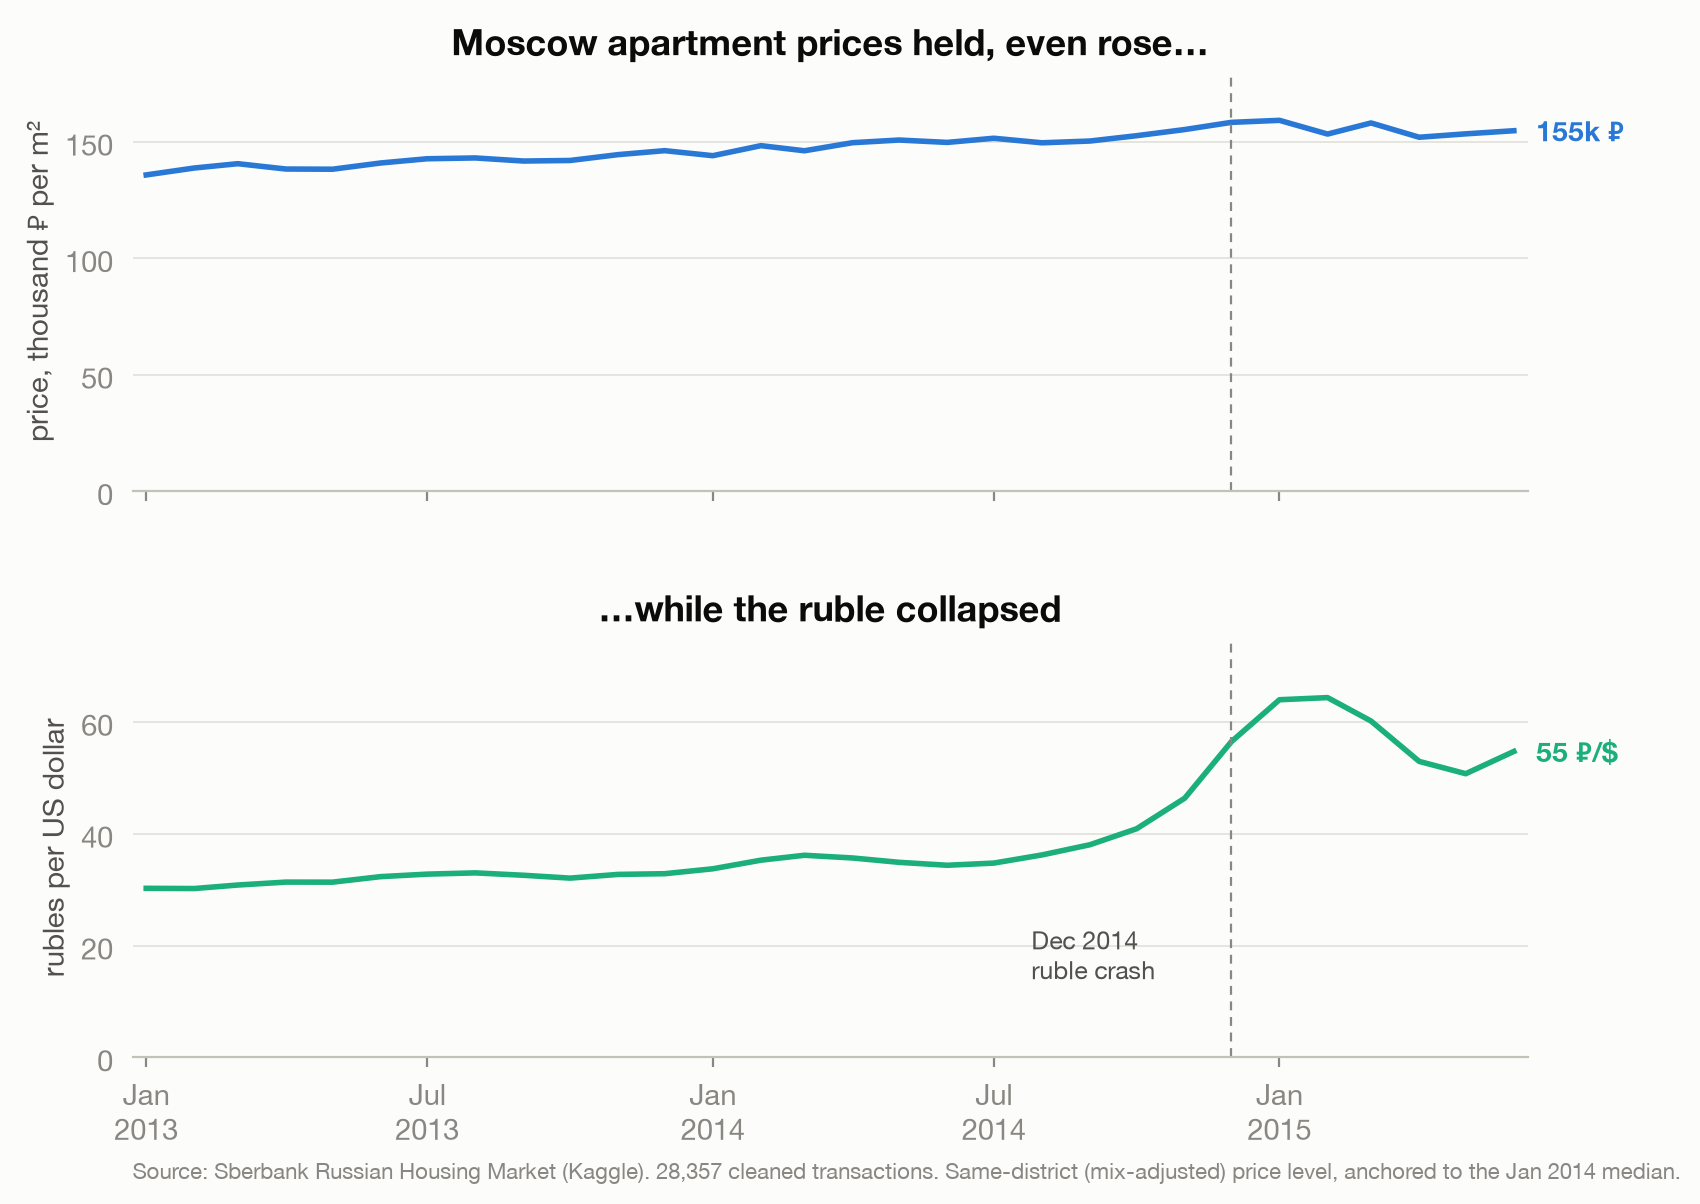

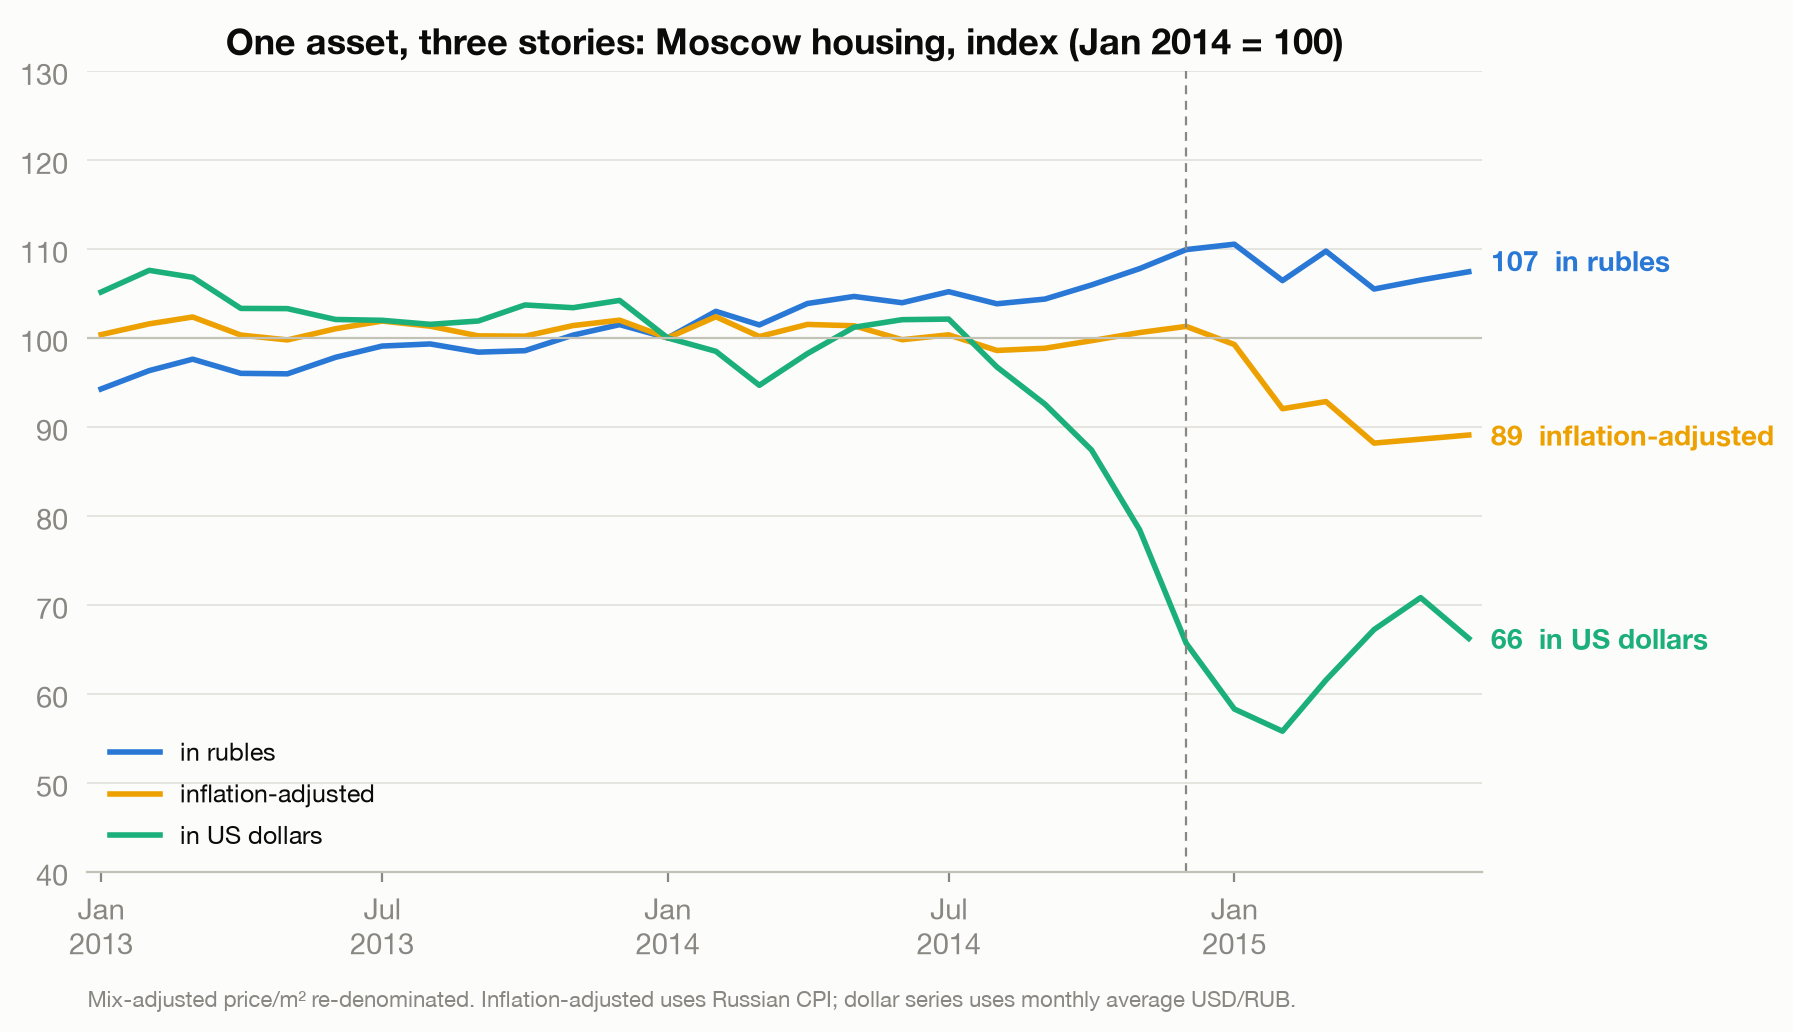

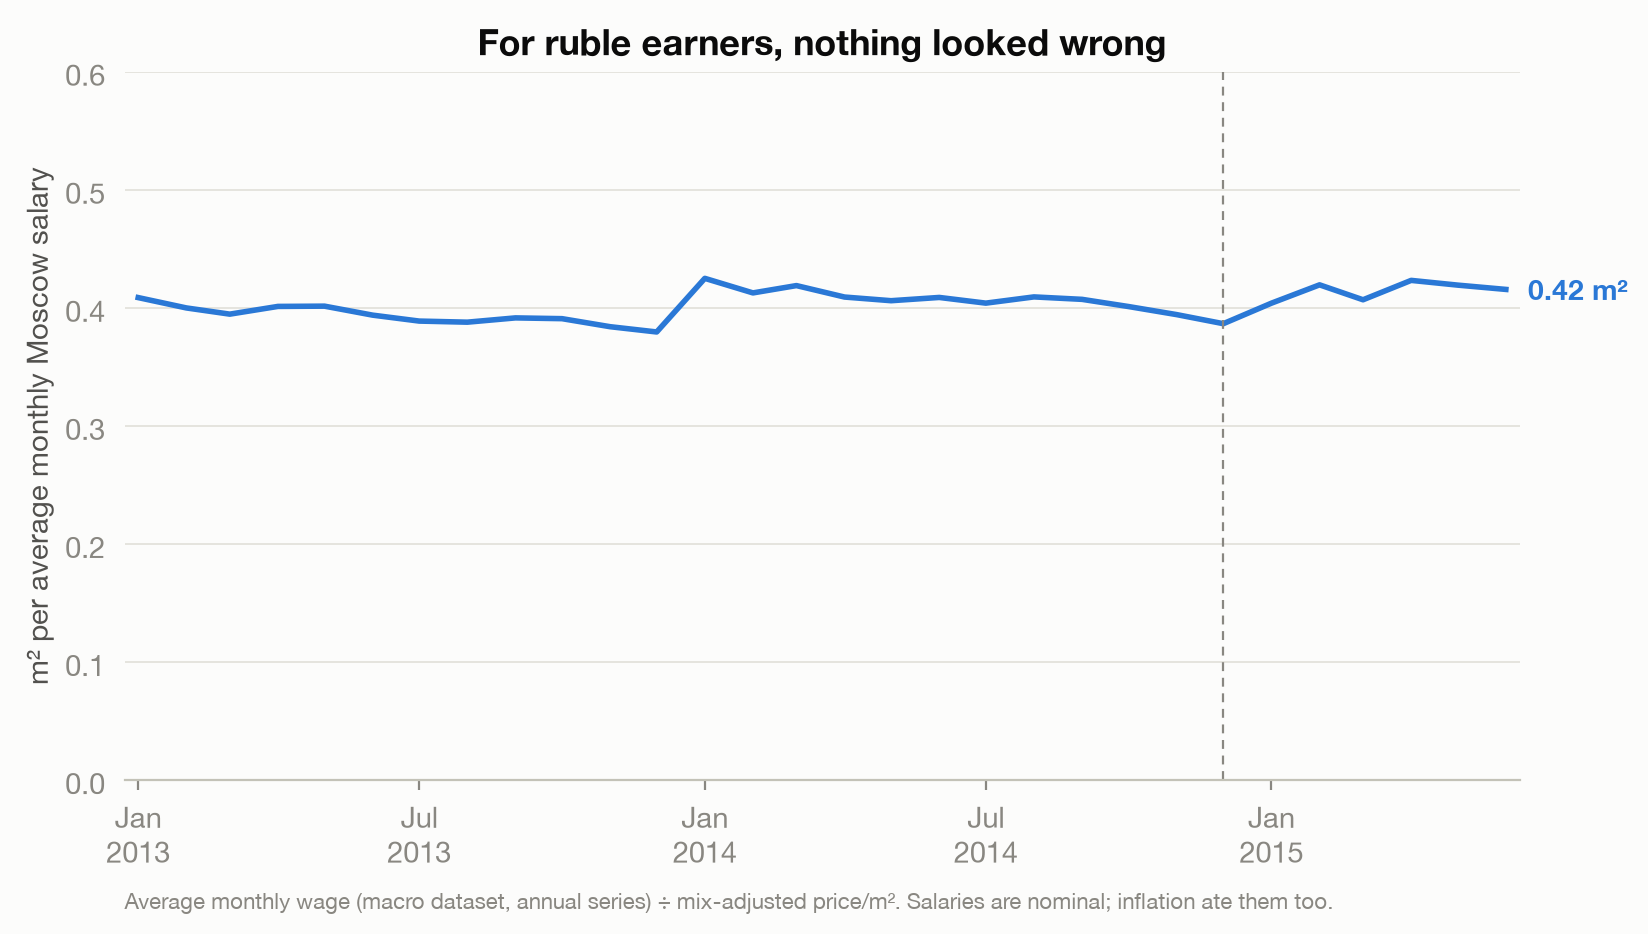

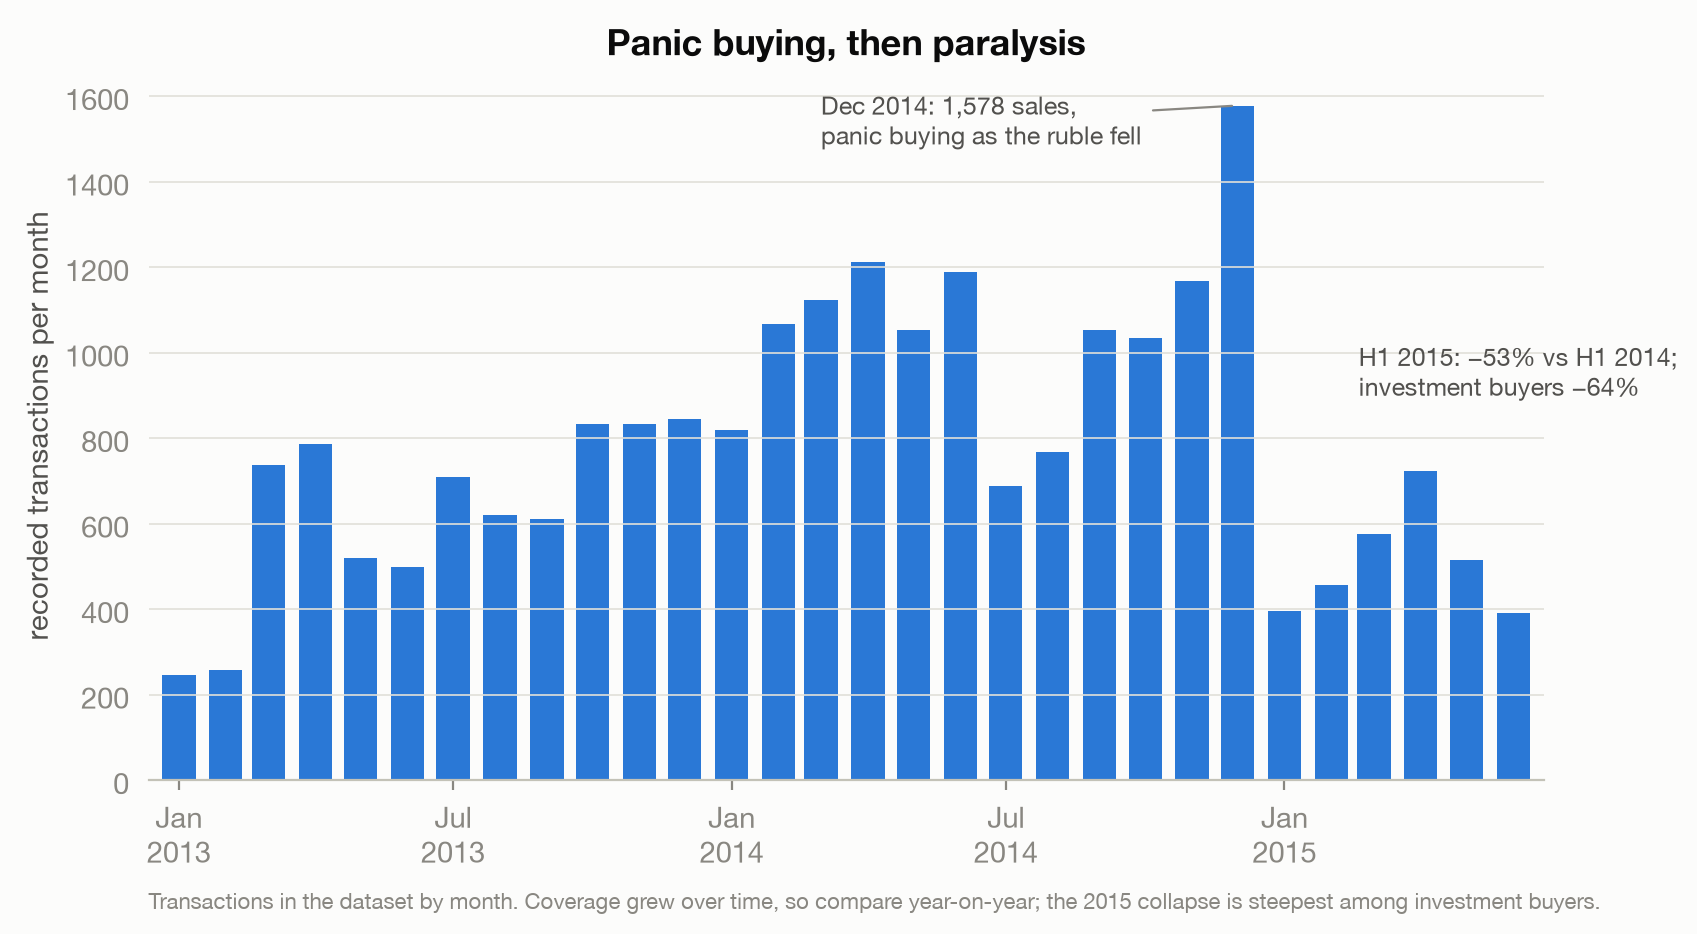

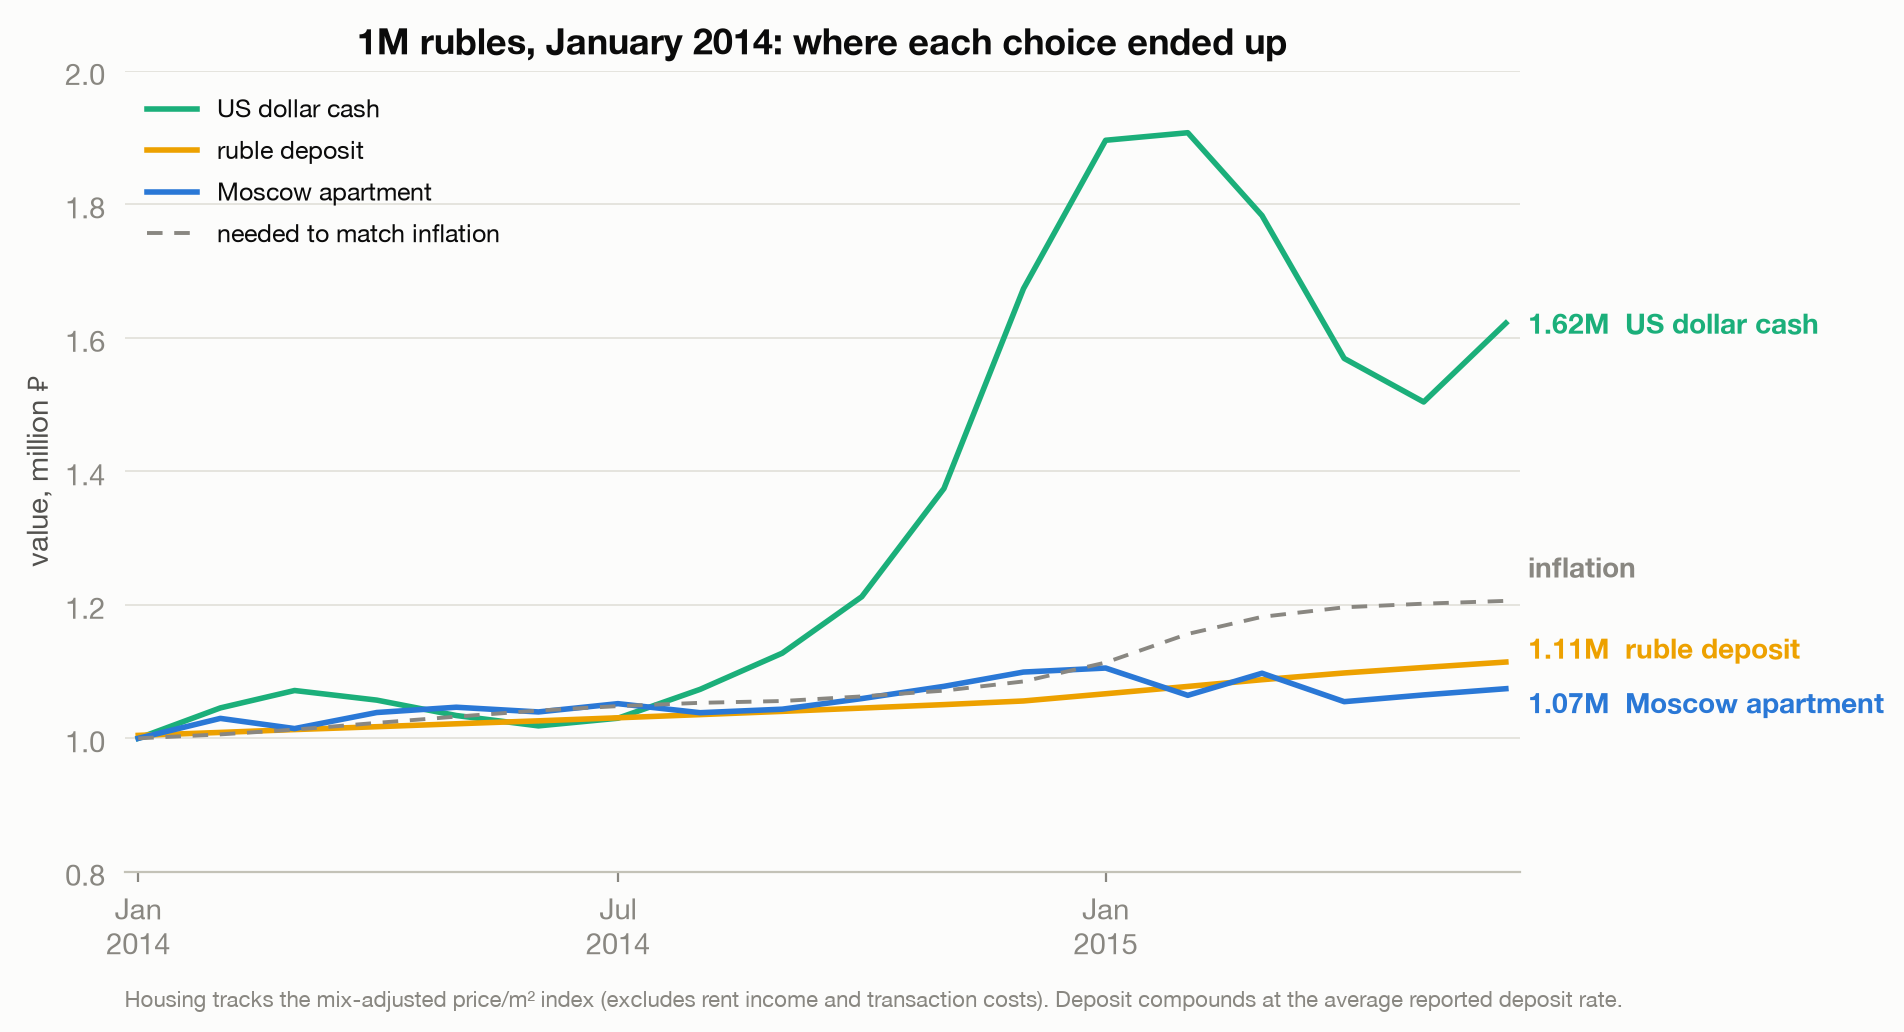

In [8]:
from IPython.display import Image, display
for name in ["01_stable_prices", "02_redenominated", "03_affordability",
             "05_volume", "04_counterfactual"]:
    display(Image(filename=f"charts/{name}.png"))

## Method and caveats

The median transaction index is not a repeat-sales index, so within-district mix
can still shift. Declared prices likely understate true prices even after cleaning.
Dataset volume partly reflects Sberbank's growing coverage, so volume is compared
year on year. The housing counterfactual excludes rent income and transaction
costs. The data ends June 2015, and the crisis did not.

Full write-up: [joechrisnaldy.app/blog/property-isnt-the-hedge-you-think](https://joechrisnaldy.app/blog/property-isnt-the-hedge-you-think).